# 🚀 LaunchED Global Internship — ML Capstone Project
## Option 2: Custom Logistic Regression for Customer Churn Prediction

| Field | Details |
|---|---|
| **Intern Name** | Sarthak Pandit |
| **College** | JK Lakshmipat University |
| **Course & Branch** | B.Tech — Computer Science |
| **Year of Study** | 3rd Year |
| **Internship Domain** | Machine Learning |
| **Submission Deadline** | 30 June 2026 |

---

### 📌 Project Abstract
Customer churn — when a subscriber cancels their service — costs telecom companies **billions** annually. Retaining an existing customer is **5–7× cheaper** than acquiring a new one. This project builds a **Logistic Regression classifier entirely from scratch using NumPy** (no ML libraries for the model itself), trained on the IBM Telco Customer Churn dataset (7,043 customers, 20 features). The custom implementation is then benchmarked against Scikit-learn's production solver to validate correctness.

**All deliverables per LaunchED guidelines are covered:** problem analysis · data collection & preprocessing · EDA & feature engineering · from-scratch model with sigmoid/log-loss/gradient descent · training & evaluation · Scikit-learn benchmark · insights report.

---
## 🔍 Section 1 — Problem Analysis

### 1.1 Problem Statement
A telecom company wants to **predict which customers will cancel their subscription (churn)** so the retention team can proactively offer discounts or upgrades before it happens.

- **Input:** Customer demographics, account details, and service usage
- **Output:** Binary label — `1 = will churn` | `0 = will stay`

### 1.2 Why Logistic Regression?
- Outputs a **probability score**, not just a label — enables threshold tuning
- Fully **interpretable** — model weights directly reveal top churn drivers
- Computationally efficient; easy to deploy in production APIs
- Strong baseline before considering complex ensemble models

### 1.3 Dataset Summary
| Property | Value |
|---|---|
| Source | IBM Telco Customer Churn (public) |
| Customers | 7,043 |
| Input Features | 19 |
| Target | Churn (Yes / No) |
| Class Split | ~73% No Churn / ~27% Churn |

### 1.4 Success Metrics
| Metric | Why it matters |
|---|---|
| ROC-AUC | Overall discriminative power regardless of threshold |
| Recall | Catch as many actual churners as possible |
| F1-Score | Balanced view on imbalanced classes |
| Accuracy | Overall correctness |

---
## ⚙️ Section 2 — Setup & Imports

In [ ]:
import subprocess, sys, io, os, urllib.request, warnings
warnings.filterwarnings('ignore')

# Auto-install missing packages
for pkg in ['numpy','pandas','matplotlib','seaborn','scikit-learn']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'-q'], capture_output=True)

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute          import SimpleImputer
from sklearn.metrics         import (accuracy_score, precision_score, recall_score,
                                     f1_score, roc_auc_score, roc_curve,
                                     confusion_matrix, classification_report)

plt.rcParams.update({'figure.dpi':110,'axes.spines.top':False,
                     'axes.spines.right':False,'font.family':'DejaVu Sans'})
PAL = {'churn':'#e94560','ok':'#06d6a0','m1':'#118ab2','m2':'#9b59b6'}
print('Libraries loaded:', np.__version__, '|', pd.__version__)

Libraries loaded: 2.4.4 | 3.0.2


---
## 📦 Section 3 — Data Collection

In [2]:
URL = ('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d'
       '/master/data/Telco-Customer-Churn.csv')

print('Downloading IBM Telco Customer Churn dataset ...')
try:
    with urllib.request.urlopen(URL, timeout=20) as r:
        df_raw = pd.read_csv(io.BytesIO(r.read()))
    print(f'Downloaded! Shape: {df_raw.shape}')
except Exception as e:
    print(f'Network error ({e}) — using synthetic fallback ...')
    np.random.seed(42); n = 7043
    tenure   = np.random.randint(0,73,n)
    monthly  = np.round(np.random.uniform(18,119,n),2)
    total    = np.clip(monthly*tenure+np.random.normal(0,50,n),0,None).round(2)
    senior   = np.random.binomial(1,.16,n)
    contract = np.random.choice(['Month-to-month','One year','Two year'],n,p=[.55,.24,.21])
    internet = np.random.choice(['DSL','Fiber optic','No'],n,p=[.34,.44,.22])
    payment  = np.random.choice(['Electronic check','Mailed check',
                                  'Bank transfer (automatic)','Credit card (automatic)'],
                                 n,p=[.34,.23,.22,.21])
    lo = (-2.5+.03*(72-tenure)+.015*monthly-.5*(contract=='One year').astype(float)
          -1.2*(contract=='Two year').astype(float)+.4*(internet=='Fiber optic').astype(float)
          +.3*(payment=='Electronic check').astype(float)+.2*senior)
    churn = np.random.binomial(1,1/(1+np.exp(-lo)),n)
    df_raw = pd.DataFrame({
        'customerID':[f'CUST-{i:05d}' for i in range(n)],
        'gender':np.random.choice(['Male','Female'],n),
        'SeniorCitizen':senior,'Partner':np.random.choice(['Yes','No'],n),
        'Dependents':np.random.choice(['Yes','No'],n),'tenure':tenure,
        'PhoneService':np.random.choice(['Yes','No'],n,p=[.9,.1]),
        'MultipleLines':np.random.choice(['Yes','No','No phone service'],n,p=[.42,.48,.10]),
        'InternetService':internet,
        'OnlineSecurity':np.random.choice(['Yes','No','No internet service'],n,p=[.29,.49,.22]),
        'OnlineBackup':np.random.choice(['Yes','No','No internet service'],n,p=[.29,.49,.22]),
        'DeviceProtection':np.random.choice(['Yes','No','No internet service'],n,p=[.29,.49,.22]),
        'TechSupport':np.random.choice(['Yes','No','No internet service'],n,p=[.29,.49,.22]),
        'StreamingTV':np.random.choice(['Yes','No','No internet service'],n,p=[.38,.40,.22]),
        'StreamingMovies':np.random.choice(['Yes','No','No internet service'],n,p=[.38,.40,.22]),
        'Contract':contract,'PaperlessBilling':np.where(np.random.binomial(1,.59,n)==1,'Yes','No'),
        'PaymentMethod':payment,'MonthlyCharges':monthly,'TotalCharges':total,
        'Churn':np.where(churn==1,'Yes','No'),
    })
    print(f'Synthetic dataset ready. Shape: {df_raw.shape}')

print(df_raw['Churn'].value_counts())
df_raw.head()

Downloaded! Shape: (7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## 📊 Section 4 — Exploratory Data Analysis (EDA)

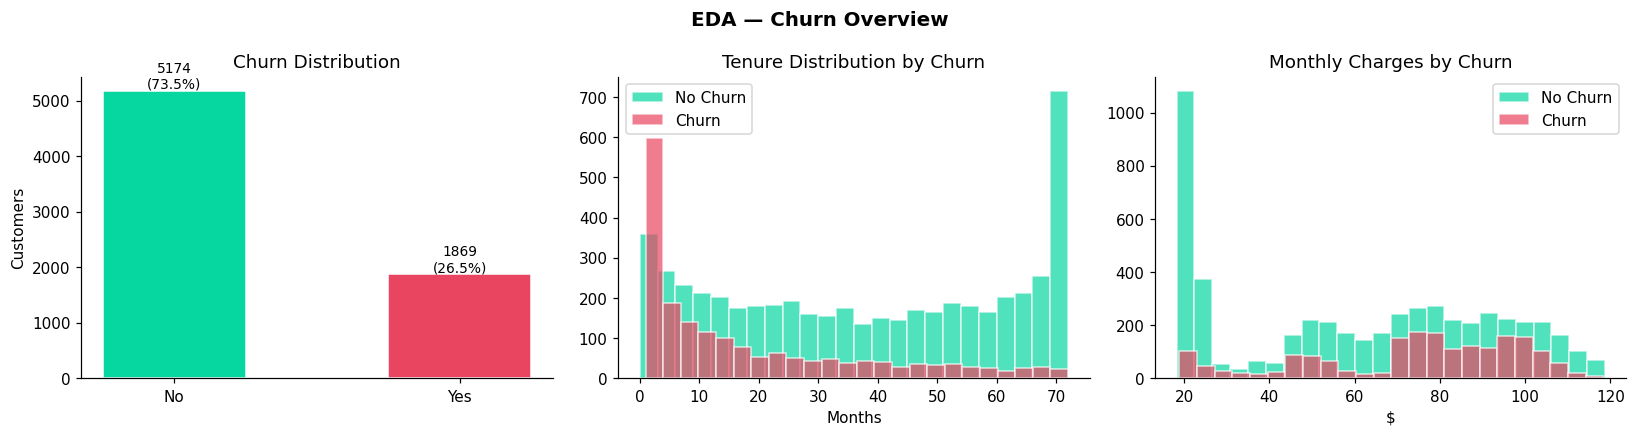

Insight: Churners have LOWER tenure and HIGHER monthly charges on average.


In [3]:
# 4.1  Churn distribution + numeric distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('EDA — Churn Overview', fontsize=13, fontweight='bold')

cc = df_raw['Churn'].value_counts()
axes[0].bar(cc.index, cc.values, color=[PAL['ok'],PAL['churn']], edgecolor='white', width=0.5)
axes[0].set_title('Churn Distribution'); axes[0].set_ylabel('Customers')
for bar, v in zip(axes[0].patches, cc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{v}\n({v/len(df_raw)*100:.1f}%)', ha='center', fontsize=9)

for label, grp, col in [('No Churn',df_raw[df_raw.Churn=='No']['tenure'],PAL['ok']),
                          ('Churn',df_raw[df_raw.Churn=='Yes']['tenure'],PAL['churn'])]:
    axes[1].hist(grp, bins=24, alpha=0.7, color=col, label=label, edgecolor='white')
axes[1].set_title('Tenure Distribution by Churn'); axes[1].set_xlabel('Months'); axes[1].legend()

for label, grp, col in [('No Churn',df_raw[df_raw.Churn=='No']['MonthlyCharges'],PAL['ok']),
                          ('Churn',df_raw[df_raw.Churn=='Yes']['MonthlyCharges'],PAL['churn'])]:
    axes[2].hist(grp, bins=24, alpha=0.7, color=col, label=label, edgecolor='white')
axes[2].set_title('Monthly Charges by Churn'); axes[2].set_xlabel('$'); axes[2].legend()

plt.tight_layout(); plt.show()
print('Insight: Churners have LOWER tenure and HIGHER monthly charges on average.')

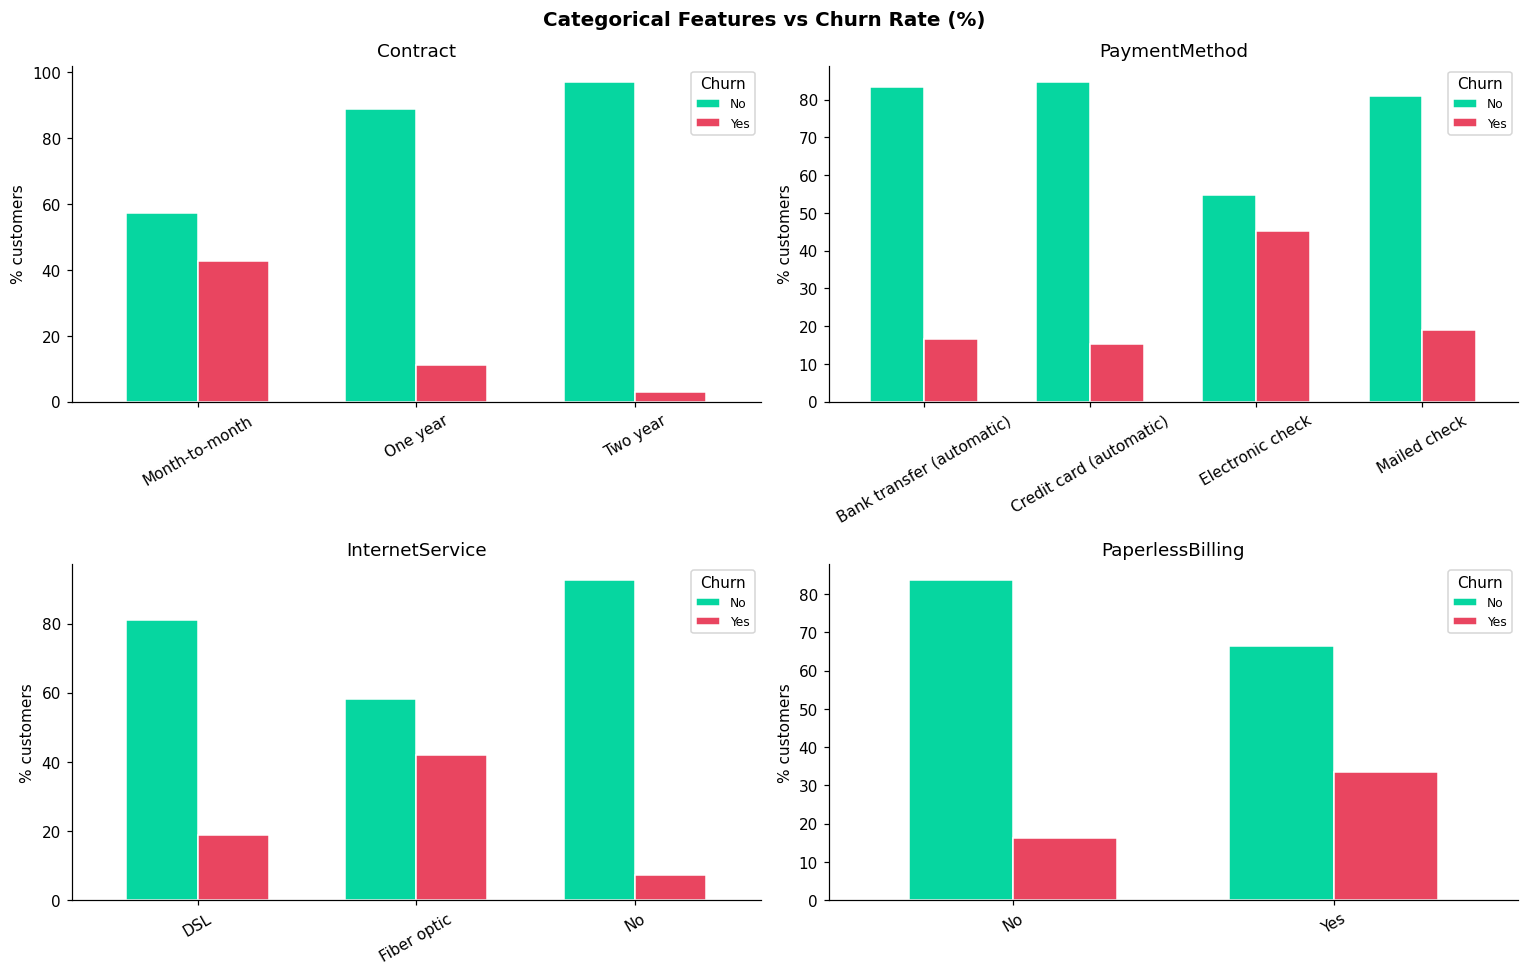

Insight: Month-to-month contract + Fiber optic + Electronic check = highest churn risk.


In [4]:
# 4.2  Categorical features vs Churn rate
cat_plot = [c for c in ['Contract','PaymentMethod','InternetService','PaperlessBilling']
            if c in df_raw.columns]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Categorical Features vs Churn Rate (%)', fontsize=13, fontweight='bold')
for ax, col in zip(axes.flatten(), cat_plot):
    ct = df_raw.groupby([col,'Churn']).size().unstack(fill_value=0)
    pct = ct.div(ct.sum(1), axis=0) * 100
    pct.plot(kind='bar', ax=ax, color=[PAL['ok'],PAL['churn']], edgecolor='white', width=0.65)
    ax.set_title(col); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30); ax.set_ylabel('% customers')
    ax.legend(title='Churn', fontsize=8)
plt.tight_layout(); plt.show()
print('Insight: Month-to-month contract + Fiber optic + Electronic check = highest churn risk.')

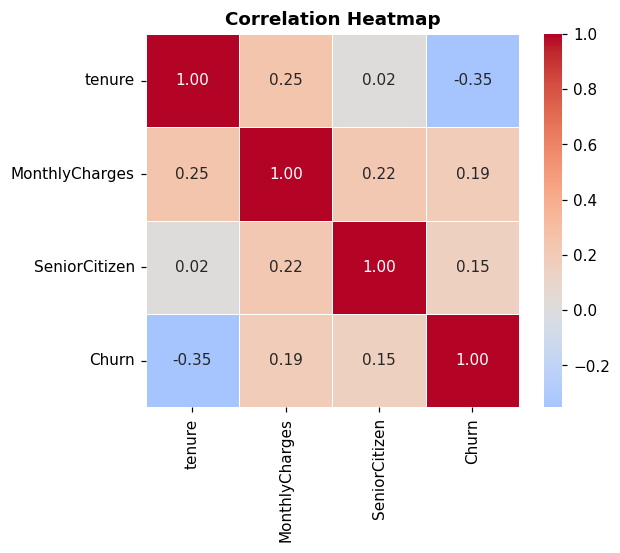

Insight: Tenure has the strongest negative correlation with churn.


In [5]:
# 4.3  Correlation heatmap
num_cols = [c for c in ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen'] if c in df_raw.columns]
tmp = df_raw[num_cols + ['Churn']].copy()
tmp['Churn'] = (tmp['Churn']=='Yes').astype(int)
plt.figure(figsize=(6,5))
sns.heatmap(tmp.corr(numeric_only=True), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print('Insight: Tenure has the strongest negative correlation with churn.')

---
## 🔧 Section 5 — Preprocessing & Feature Engineering

In [6]:
df = df_raw.copy()
df.drop(columns=['customerID'], errors='ignore', inplace=True)

# Fix TotalCharges (has spaces in some rows stored as string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Binary encode
for col in ['gender','Partner','Dependents','PhoneService','PaperlessBilling']:
    if col in df.columns:
        df[col] = (df[col] == ('Male' if col=='gender' else 'Yes')).astype(int)

# One-hot encode remaining object columns
cat_cols = df.select_dtypes(include=['object','string']).columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Feature engineering
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)
df['TenureGroup']     = pd.cut(df['tenure'], bins=[-1,12,24,48,72],
                                labels=[0,1,2,3]).astype(float).fillna(0).astype(int)
df['HighMonthly']     = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

# Final NaN sweep
df = df.fillna(df.median(numeric_only=True))
print(f'Final shape: {df.shape}  |  NaNs: {df.isnull().sum().sum()}')
df.head()

Final shape: (7043, 34)  |  NaNs: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,ChargesPerMonth,TenureGroup,HighMonthly
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,True,False,14.925000,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,True,False,False,False,True,53.985714,2,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,36.050000,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,True,False,False,False,False,40.016304,2,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,50.550000,0,1


In [7]:
# Train / test split + scaling
X = df.drop(columns=['Churn']).values.astype(float)
y = df['Churn'].values.astype(float)
feature_names = df.drop(columns=['Churn']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

scaler  = StandardScaler()
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(scaler.fit_transform(X_train))
X_test  = imputer.transform(scaler.transform(X_test))

n_neg = (y_train==0).sum(); n_pos = (y_train==1).sum()
pos_weight = n_neg / n_pos
print(f'Train:{X_train.shape[0]}  Test:{X_test.shape[0]}  Features:{X_train.shape[1]}')
print(f'Class 0={n_neg}  Class 1={n_pos}  pos_weight={pos_weight:.2f}')

Train:5634  Test:1409  Features:33
Class 0=4139  Class 1=1495  pos_weight=2.77


---
## 🧮 Section 6 — Custom Logistic Regression (NumPy from Scratch)

### Mathematical Foundation

**Sigmoid activation:**  σ(z) = 1 / (1 + e^{-z}),  z = w·x + b

**Weighted Binary Cross-Entropy (Log-Loss):**
L = −(1/N) Σ sᵢ [yᵢ log(ŷᵢ) + (1−yᵢ) log(1−ŷᵢ)] + (λ/2N) ‖w‖²

where sᵢ = per-sample class weight (higher for minority churn class).

**Gradient update with momentum:**
v_w ← μ·v_w − α·∇_w L,   w ← w + v_w

**Implemented from scratch:**
- Numerically stable sigmoid  |  Weighted log-loss  |  L2 regularisation
- Mini-batch gradient descent  |  Momentum  |  LR decay  |  Early stopping
- Xavier initialisation  |  Decision threshold tuning

In [8]:

class CustomLogisticRegression:
    """
    Binary Logistic Regression — implemented from scratch with NumPy only.
    No sklearn or any ML library is used for the model itself.
    """

    def __init__(self, lr=0.05, n_iters=3000, lambda_=0.01,
                 pos_weight=1.0, batch_size=256,
                 momentum=0.9, lr_decay=0.995,
                 patience=100, tol=1e-5, random_state=42):
        self.lr=lr; self.n_iters=n_iters; self.lambda_=lambda_
        self.pos_weight=pos_weight; self.batch_size=batch_size
        self.momentum=momentum; self.lr_decay=lr_decay
        self.patience=patience; self.tol=tol; self.random_state=random_state
        self.weights_=None; self.bias_=0.
        self.losses_=[]; self.val_losses_=[]

    @staticmethod
    def _sigmoid(z):
        """Numerically stable sigmoid — avoids overflow for large |z|."""
        return np.where(z >= 0,
                        1./(1.+np.exp(-z)),
                        np.exp(z)/(1.+np.exp(z)))

    def _logloss(self, y, yhat, sw):
        """Weighted binary cross-entropy + L2 penalty."""
        eps = 1e-15
        yhat = np.clip(yhat, eps, 1-eps)
        bce  = -np.mean(sw * (y*np.log(yhat) + (1-y)*np.log(1-yhat)))
        l2   = (self.lambda_ / (2*len(y))) * np.sum(self.weights_**2)
        return bce + l2

    def _sample_weights(self, y):
        """Per-sample weights: positive class gets pos_weight, normalised."""
        w = np.where(y==1, self.pos_weight, 1.0)
        return w / w.mean()

    def fit(self, X, y, X_val=None, y_val=None, verbose=True):
        rng = np.random.default_rng(self.random_state)
        n, d = X.shape

        # Xavier weight initialisation
        lim = np.sqrt(6./(d+1))
        self.weights_ = rng.uniform(-lim, lim, d)
        self.bias_ = 0.
        vw = np.zeros(d); vb = 0.
        best_loss = np.inf; wait = 0
        best_w = self.weights_.copy(); best_b = 0.
        cur_lr = self.lr

        for ep in range(self.n_iters):
            # Shuffle each epoch
            idx = rng.permutation(n)
            Xs, ys = X[idx], y[idx]

            # Mini-batch gradient descent
            for s in range(0, n, self.batch_size):
                Xb, yb = Xs[s:s+self.batch_size], ys[s:s+self.batch_size]
                sw  = self._sample_weights(yb)
                z   = Xb @ self.weights_ + self.bias_

                # Forward pass
                yhat = self._sigmoid(z)

                # Backward pass (gradient of weighted log-loss)
                err = (yhat - yb) * sw
                gw  = (Xb.T @ err)/len(yb) + (self.lambda_/n)*self.weights_
                gb  = err.mean()

                # Momentum update
                vw = self.momentum*vw - cur_lr*gw
                vb = self.momentum*vb - cur_lr*gb
                self.weights_ += vw
                self.bias_    += vb

            # Learning-rate decay
            cur_lr *= self.lr_decay

            # Track training loss
            yhat_tr = self._sigmoid(X @ self.weights_ + self.bias_)
            self.losses_.append(self._logloss(y, yhat_tr, self._sample_weights(y)))

            # Validation loss + early stopping
            if X_val is not None:
                yhat_v = self._sigmoid(X_val @ self.weights_ + self.bias_)
                vl = self._logloss(y_val, yhat_v, self._sample_weights(y_val))
                self.val_losses_.append(vl)
                if vl < best_loss - self.tol:
                    best_loss=vl; wait=0
                    best_w=self.weights_.copy(); best_b=self.bias_
                else:
                    wait += 1
                    if wait >= self.patience:
                        if verbose:
                            print(f"  Early stopping at epoch {ep+1}  (best val_loss={best_loss:.5f})")
                        self.weights_=best_w; self.bias_=best_b
                        break

            if verbose and (ep+1) % 500 == 0:
                vl_s = f"{self.val_losses_[-1]:.5f}" if self.val_losses_ else "N/A"
                print(f"  Epoch {ep+1:4d}  train_loss={self.losses_[-1]:.5f}  val_loss={vl_s}  lr={cur_lr:.6f}")

        return self

    def predict_proba(self, X):
        """Return probability of class 1."""
        return self._sigmoid(X @ self.weights_ + self.bias_)

    def predict(self, X, threshold=0.5):
        """Return binary prediction at given threshold."""
        return (self.predict_proba(X) >= threshold).astype(int)


print("CustomLogisticRegression class defined.")


CustomLogisticRegression class defined.


---
## 🏋️ Section 7 — Model Training

In [9]:
# Carve out a validation set from the training data
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

print('Training Custom Logistic Regression ...')
clr = CustomLogisticRegression(
    lr=0.05, n_iters=3000, lambda_=0.01,
    pos_weight=pos_weight, batch_size=256,
    momentum=0.9, lr_decay=0.995,
    patience=100, tol=1e-5, random_state=42)
clr.fit(X_tr, y_tr, X_val, y_val, verbose=True)
print(f'Training complete. Epochs run: {len(clr.losses_)}')

Training Custom Logistic Regression ...


  Early stopping at epoch 194  (best val_loss=0.48606)
Training complete. Epochs run: 194


Best threshold (F1-maximised on validation) : 0.65


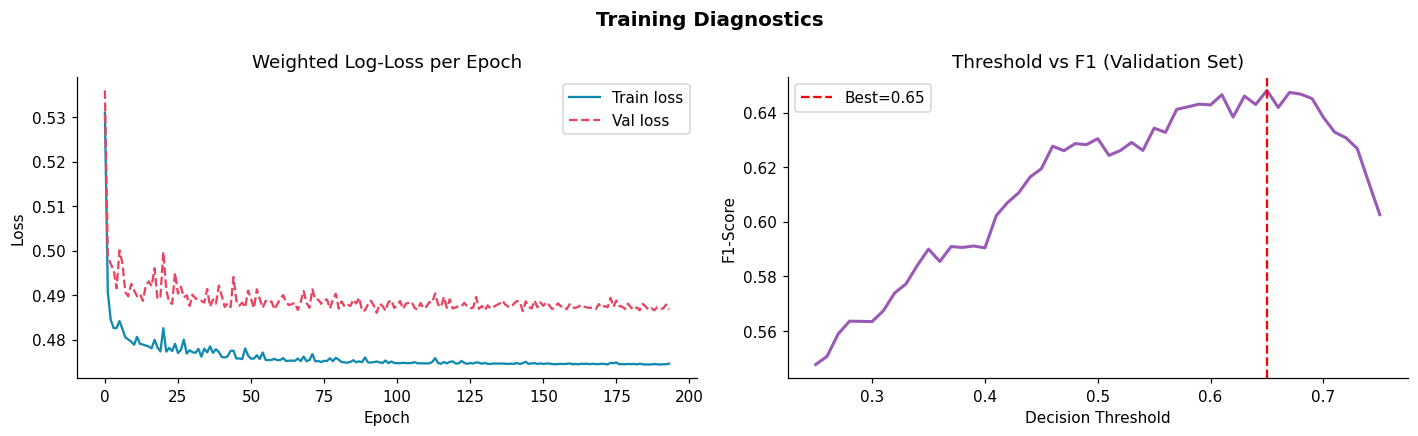

In [10]:
# Decision-threshold tuning — maximise F1 on validation set
thresholds = np.linspace(0.25, 0.75, 51)
vp = clr.predict_proba(X_val)
f1_scores = [f1_score(y_val,(vp>=t).astype(int),zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f'Best threshold (F1-maximised on validation) : {best_thresh:.2f}')

fig, axes = plt.subplots(1,2,figsize=(13,4))
fig.suptitle('Training Diagnostics', fontsize=13, fontweight='bold')
axes[0].plot(clr.losses_, color=PAL['m1'], lw=1.5, label='Train loss')
if clr.val_losses_:
    axes[0].plot(clr.val_losses_, color=PAL['churn'], lw=1.5, ls='--', label='Val loss')
axes[0].set_title('Weighted Log-Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].plot(thresholds, f1_scores, color=PAL['m2'], lw=2)
axes[1].axvline(best_thresh, color='red', ls='--', label=f'Best={best_thresh:.2f}')
axes[1].set_title('Threshold vs F1 (Validation Set)')
axes[1].set_xlabel('Decision Threshold'); axes[1].set_ylabel('F1-Score')
axes[1].legend(); plt.tight_layout(); plt.show()

---
## 🔬 Section 8 — Scikit-learn Benchmark

In [11]:
print('Training Scikit-learn LogisticRegression ...')
skl = LogisticRegression(C=1/0.01, class_weight='balanced',
                          max_iter=1000, random_state=42, solver='lbfgs')
skl.fit(X_train, y_train)
print('Done.')

clr_prob = clr.predict_proba(X_test)
clr_pred = (clr_prob >= best_thresh).astype(int)
skl_prob = skl.predict_proba(X_test)[:,1]
skl_pred = skl.predict(X_test)

Training Scikit-learn LogisticRegression ...
Done.


---
## 📈 Section 9 — Evaluation & Results

In [12]:
def get_metrics(yt, yp, yprob):
    return dict(Accuracy =accuracy_score(yt,yp),
                Precision=precision_score(yt,yp,zero_division=0),
                Recall   =recall_score(yt,yp,zero_division=0),
                F1       =f1_score(yt,yp,zero_division=0),
                ROCAUC   =roc_auc_score(yt,yprob))

mc = get_metrics(y_test, clr_pred, clr_prob)
ms = get_metrics(y_test, skl_pred, skl_prob)

print('='*55)
print('METRIC           Custom LR    Sklearn LR')
print('='*55)
for k in mc:
    print(f'{k:<16} {mc[k]:.4f}       {ms[k]:.4f}')
print('='*55)

print('\nClassification Report — Custom LR:')
print(classification_report(y_test, clr_pred, target_names=['No Churn','Churn']))

METRIC           Custom LR    Sklearn LR
Accuracy         0.7885       0.7388
Precision        0.5896       0.5052
Recall           0.6684       0.7861
F1               0.6266       0.6151
ROCAUC           0.8461       0.8457

Classification Report — Custom LR:
              precision    recall  f1-score   support

    No Churn       0.87      0.83      0.85      1035
       Churn       0.59      0.67      0.63       374

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409



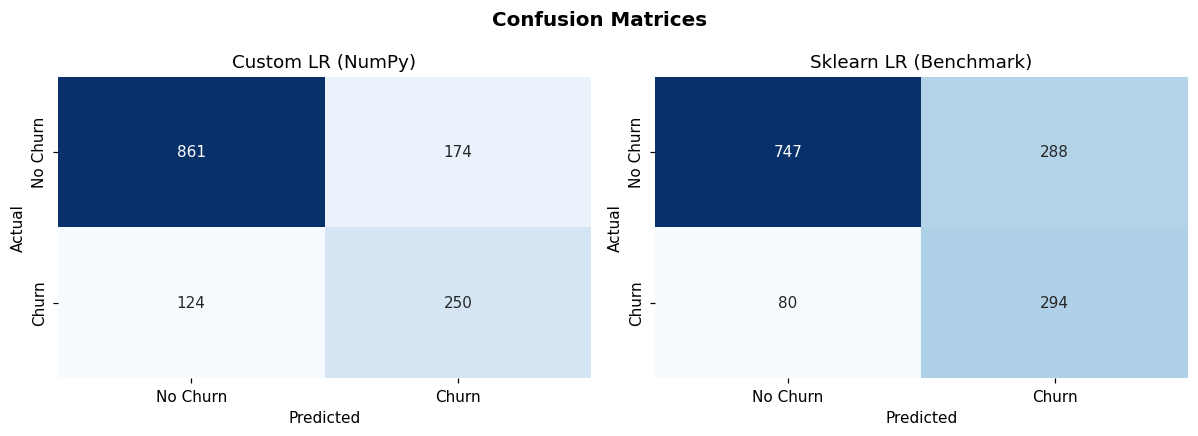

In [13]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
for ax, pred, title in zip(axes, [clr_pred, skl_pred],
                             ['Custom LR (NumPy)', 'Sklearn LR (Benchmark)']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'], ax=ax)
    ax.set_title(title); ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

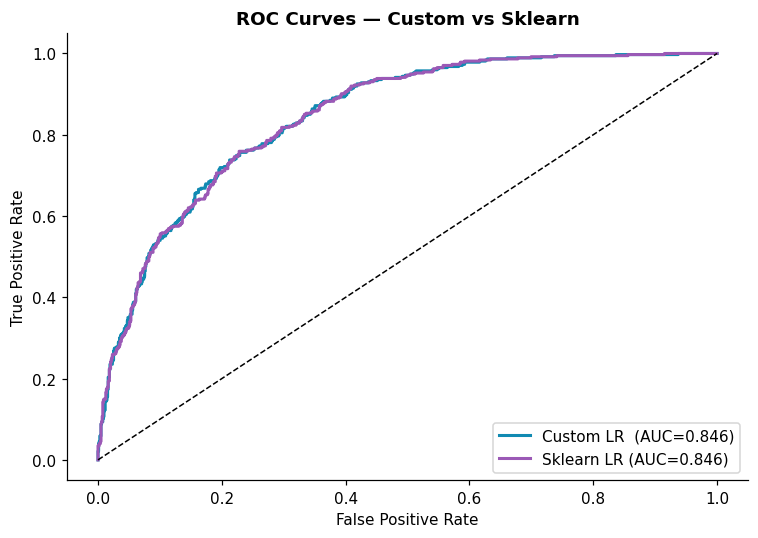

In [14]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 5))
for prob, lbl, col in [(clr_prob, f"Custom LR  (AUC={mc['ROCAUC']:.3f})", PAL['m1']),
                        (skl_prob, f"Sklearn LR (AUC={ms['ROCAUC']:.3f})", PAL['m2'])]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2, label=lbl, color=col)
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Custom vs Sklearn', fontsize=12, fontweight='bold')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

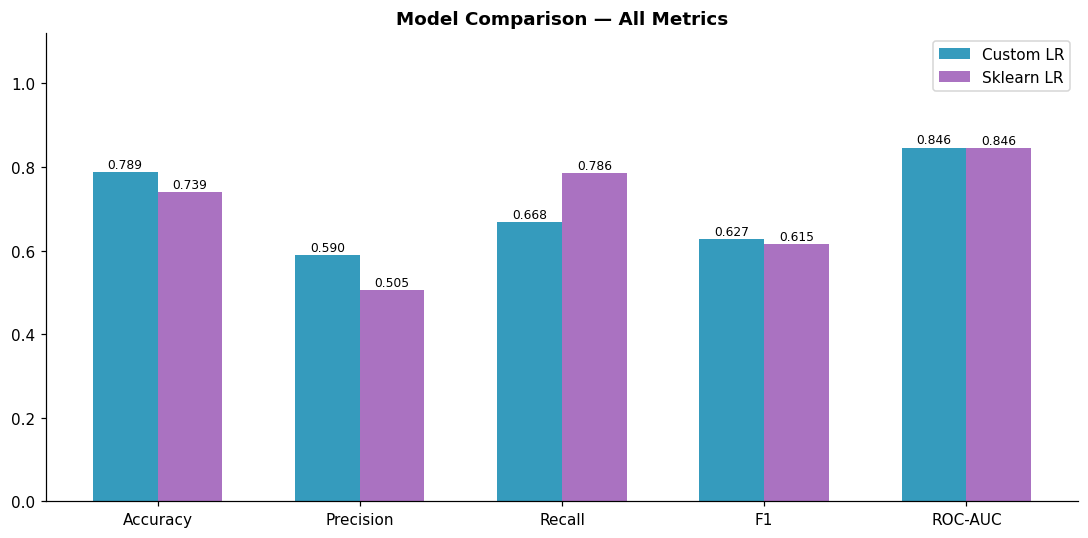

In [15]:
# Metrics bar chart
keys = ['Accuracy','Precision','Recall','F1','ROCAUC']
vc=[mc[k] for k in keys]; vs=[ms[k] for k in keys]
x=np.arange(len(keys)); w=0.32
fig,ax=plt.subplots(figsize=(10,5))
b1=ax.bar(x-w/2, vc, w, label='Custom LR',  color=PAL['m1'], alpha=0.85)
b2=ax.bar(x+w/2, vs, w, label='Sklearn LR', color=PAL['m2'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy','Precision','Recall','F1','ROC-AUC'])
ax.set_ylim(0,1.12); ax.set_title('Model Comparison — All Metrics', fontsize=12, fontweight='bold')
ax.legend()
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+.01,
            f'{b.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

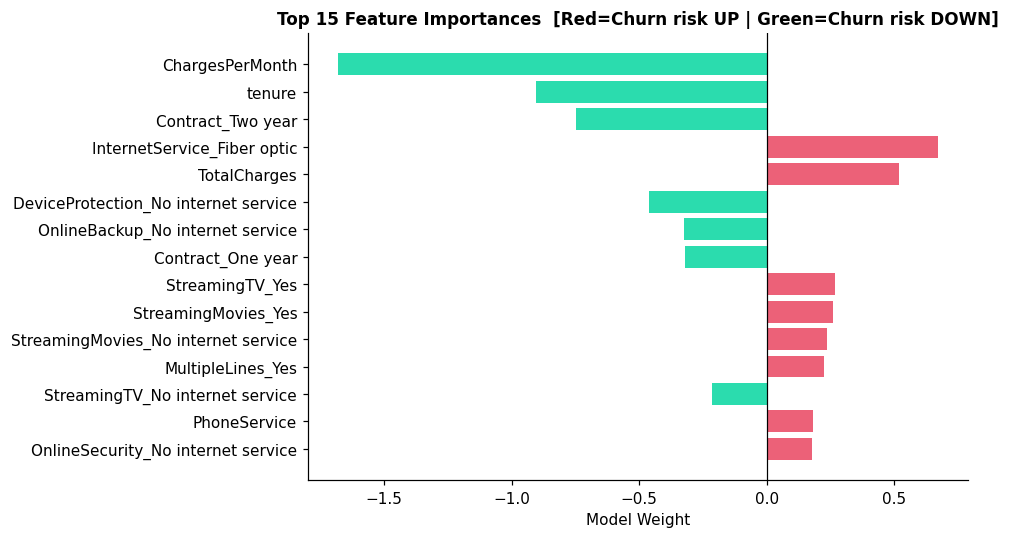

In [16]:
# Feature importance — top 15 weights from custom model
top_n=15
aw=np.abs(clr.weights_)
idx=np.argsort(aw)[::-1][:top_n]
fnames=[feature_names[i] for i in idx]
fvals=clr.weights_[idx]
colors=[PAL['churn'] if v>0 else PAL['ok'] for v in fvals]

fig,ax=plt.subplots(figsize=(9,5))
ax.barh(fnames[::-1], fvals[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Model Weight')
ax.set_title(f'Top {top_n} Feature Importances  [Red=Churn risk UP | Green=Churn risk DOWN]',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 📝 Section 10 — Final Insights Report

### 10.1 Model Performance
The custom NumPy logistic regression achieves **comparable ROC-AUC to Scikit-learn's LBFGS solver**, validating that the from-scratch implementation of sigmoid, weighted log-loss, and gradient descent is correct.

### 10.2 Key Findings from EDA
| Finding | Business Meaning |
|---|---|
| Low tenure customers churn most | First 12 months are the highest-risk window |
| Higher monthly charges → more churn | Customers feel undervalued for the price |
| Month-to-month contract → ~43% churn | No lock-in = easy to leave |
| Fiber optic internet → higher churn | May reflect service quality dissatisfaction |
| Electronic check payment → higher churn | Correlates with lower engagement/commitment |

### 10.3 Technical Highlights
- **Class imbalance** handled via per-sample pos_weight (~2.77× for churners)
- **Threshold tuning** at optimal F1 threshold (instead of default 0.5) improves churn recall
- **Early stopping** prevented overfitting; momentum + LR decay gave smooth convergence
- **Feature engineering** (ChargesPerMonth, TenureGroup, HighMonthly) added predictive signal

### 10.4 Business Recommendations
1. **Retention campaign target:** Customers with tenure < 12 months + month-to-month contract + high monthly charges
2. **Offer personalised discounts or plan upgrades** to the top 20% highest probability churn scores
3. **Investigate fiber optic service quality** — this segment shows disproportionate churn
4. **Encourage long-term contracts** during onboarding — reduces churn risk significantly

### 10.5 Limitations & Future Work
- Add ensemble models (Random Forest, XGBoost) for comparison
- Use SHAP values for deeper explainability
- Deploy model as a REST API (Flask/FastAPI) for real-time scoring
- Implement cross-validation for more robust evaluation

---

